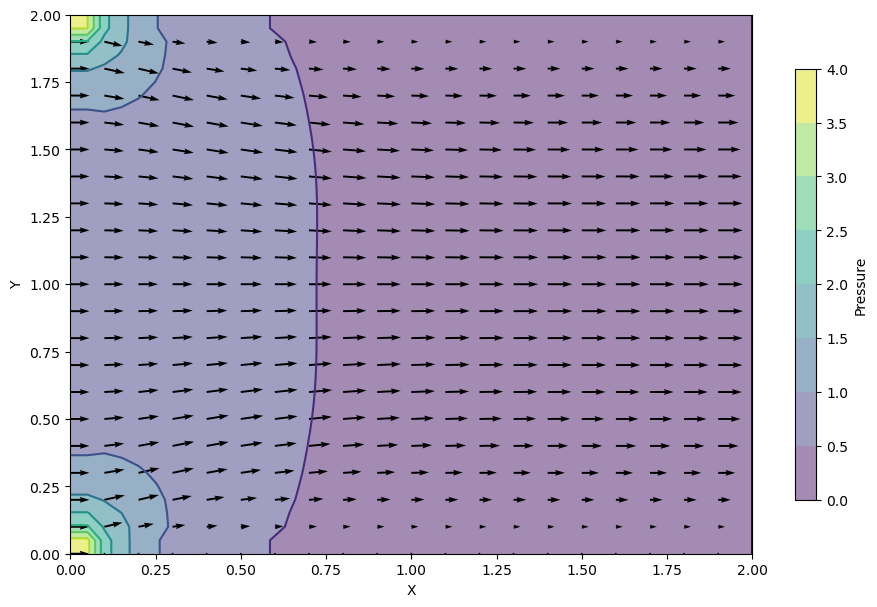

In [29]:
# Step 11: Cavity Flow with Navier–Stokes

import numpy
from matplotlib import pyplot, cm
from mpl_toolkits.mplot3d import Axes3D

nx = 41
ny = 41
nt = 500
nit = 50  # 压力的迭代次数
c = 1
dx = 2 / (nx -1)    # 0.05
dy = 2 / (ny -1)
x = numpy.linspace(0, 2, nx)   # 生成向量
y = numpy.linspace(0, 2, ny)
X, Y = numpy.meshgrid(x,y)     # 生成二维网格矩阵

rho = 1     # 无量纲后密度
nu = 0.1    # 粘度
dt = 0.001  # 时间步长

u = numpy.zeros((ny, nx))
v = numpy.zeros((ny, nx))
p = numpy.zeros((ny, nx))
b = numpy.zeros((ny, nx))  # 压力泊松方程的右端项（源项）初始化为0

# ---------泊松方程----------
# 速度部分 右端项（包含速度散度和非线性对流项）

def build_up_b(b, rho, dt, u, v, dx, dy):
    
    b[1:-1, 1:-1] = (rho * (1 / dt * 
                    ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx) + 
                    (v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy)) -
                    ((u[1:-1, 2:] - u[1:-1, 0:-2]) / (2 * dx))**2 -
                    2 * ((u[2:, 1:-1] - u[0:-2, 1:-1]) / (2 * dy) * 
                        (v[1:-1, 2:] - v[1:-1, 0:-2]) / (2 * dx)) -
                    ((v[2:, 1:-1] - v[0:-2, 1:-1]) / (2 * dy))**2))
    
    return b

# 压力部分 压力场 p


def pressure_poisson(p, dx, dy, b):
    pn = numpy.empty_like(p)        # 临时数组，存储上一轮迭代的压力场
    pn = p.copy()

    for q in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[1:-1, 2:] + pn[1:-1, 0:-2]) * dy**2 +
        (pn[2:, 1:-1] + pn[0:-2, 1:-1]) * dx**2) / 
        (2 * (dx**2 + dy**2)) - 
        dx**2 * dy**2 / (2 * (dx**2 +dy**2)) * 
        b[1:-1, 1:-1])

        p[:, -1] = 0 # 右 dp/dx=0 x=2
        p[0, :] = p[1, :]   # 下 dp/dy=0 y=0
        p[:, 0] = p[:, 1]   # 左 dp/dx=0 x=0
        p[-1, :] = p[-2, :]      # 上 p=0 y=2

    return p

def cavity_flow(nt, u, v, dt, dx, dy, p, rho, nu):
    un = numpy.empty_like(u)   # 临时数组，存储上一时间步的u
    vn = numpy.empty_like(v)
    b = numpy.zeros((ny, nx))

    for n in range(nt):
        un = u.copy()          # 保存上一时间步的u
        vn = v.copy()

        b = build_up_b(b, rho, dt, u, v, dx, dy)  # 计算压力泊松方程的右端项b
        p = pressure_poisson(p, dx, dy, b)        # 求解压力场p

        u[1:-1, 1:-1] = (un[1:-1, 1:-1] - 
                         un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[1:-1, 0:-2]) - 
                         vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[0:-2, 1:-1]) -
                         dt / (2 * rho * dx) * (p[1:-1, 2:] - p[1:-1, 0:-2]) + 
                         nu * (dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2]) + 
                         dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])))

        v[1:-1,1:-1] = (vn[1:-1, 1:-1] -
                        un[1:-1, 1:-1] * dt / dx *
                       (vn[1:-1, 1:-1] - vn[1:-1, 0:-2]) -
                        vn[1:-1, 1:-1] * dt / dy *
                       (vn[1:-1, 1:-1] - vn[0:-2, 1:-1]) -
                        dt / (2 * rho * dy) * (p[2:, 1:-1] - p[0:-2, 1:-1]) +
                        nu * (dt / dx**2 *
                       (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2]) +
                        dt / dy**2 *
                       (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])))

        # set velocity on cavity lid equal to 1

        u[0, :] = 0  # 下 u=0 无滑移
        u[:, 0] = 1  # 左 u=0
        u[:, -1] = u[:, -2] # 右 u=0
        u[-1, :] = 0 # 上 u=1

        v[:, 0] = 0  # 左 v=0
        v[:, -1] = v[:, -2] # 右 v=0
        v[0, :] = 0  # 下 v=0
        v[-1, :] = 0 # 上 v=0

    return u, v, p

u = numpy.zeros((ny, nx))      # 重新初始化u（确保初始条件干净）
v = numpy.zeros((ny, nx))
p = numpy.zeros((ny, nx))
b = numpy.zeros((ny, nx))
nt = 500                       # 时间步数
u, v, p = cavity_flow(nt, u, v, dt, dx, dy, p, rho, nu)

fig = pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.contourf(X, Y, p, alpha=0.5, cmap=cm.viridis)
pyplot.colorbar(label='Pressure', shrink=0.8)

pyplot.contour(X, Y, p, cmap=cm.viridis)

pyplot.xlabel('X')
pyplot.ylabel('Y');

# 速度矢量图
pyplot.quiver(X[::2, ::2], Y[::2, ::2], u[::2, ::2], v[::2, ::2]) # 绘制速度矢量图（quiver），每隔2个点画一个箭头（避免太密）

# 流线图
# pyplot.streamplot(X, Y, u, v)